In [1]:
library(limma)
library(dplyr)
library(ggplot2)
library(edgeR)
library(stringr)
library(reshape2)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
exp_df <- read.csv('/home/nilabjab/cancer_dependency_project_nilabja/cancer_dependency_project/Approach3_Latent_factor/Fresh_FORGE/Data/Exp.csv', 
  header = T, row.names = 1)
head(exp_df)

,A1BG,A1BG.AS1,A2M,A4GALT,AAAS,AACS,AADAT,AAGAB,AAK1,AAMDC,⋯,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
127399,1.33585123,2.837184,-0.4757615,3.522372,5.289224,5.436261,1.912285,6.170977,5.486915,5.2589014,⋯,6.255815,7.125433,0.9700382,3.911810,3.513628,3.6713206,5.387186,7.657886,4.690012,5.671180
143B,0.50502144,1.146315,4.0206406,2.191379,5.726666,3.992820,3.975156,6.908841,4.667542,2.9568233,⋯,7.219736,7.134179,1.4876841,4.076379,4.290047,3.9134273,4.413880,7.452491,5.690861,6.489629
170MGBA,-6.34365096,-1.951334,7.9345323,3.568739,4.676171,4.810112,2.668508,6.323091,6.443912,3.2753462,⋯,5.663259,4.028126,2.9669618,4.290252,4.614660,-7.9286135,6.486930,7.582614,6.399150,7.430827
22RV1,-0.05089222,2.802209,2.9740419,-2.257672,6.130935,6.428204,3.251642,6.020554,6.088325,0.6373114,⋯,6.658125,7.350443,1.1318189,3.456761,4.554439,-1.2478247,5.552063,4.451671,5.854928,5.957179
2313287,-4.77226339,-1.602338,-4.7722634,1.264826,5.211839,4.931832,-4.241749,6.394806,5.462554,2.0450756,⋯,6.162984,6.500690,1.9419821,4.451470,4.655631,-3.8547255,5.514551,5.788176,5.886246,6.400234
253J,0.40139481,1.527828,-2.0953405,3.717680,6.460873,5.066240,-4.808059,7.432302,6.160688,2.4514232,⋯,5.223987,6.001888,3.9187273,4.247525,4.068799,0.6909014,4.730023,7.069439,6.007592,5.257582


In [3]:
dim(exp_df)

[1]  1076 16289

In [4]:
# genes as rows and samples as cols
exp_data <- t(exp_df)
head(exp_data)

,127399,143B,170MGBA,22RV1,2313287,253J,253JBV,42MGBA,5637,59M,⋯,YAPC,YD15,YD38,YD8,YH13,YKG1,YSCCC,YUHOIN,Z138,ZR751
A1BG,1.3358512,0.5050214,-6.343651,-0.05089222,-4.772263,0.4013948,-1.5065185,3.4790754,-4.306551,3.0841155476,⋯,-3.5513311,-1.1348498,-3.621313,-0.404946,2.4096029,2.210062324,1.870461,0.9820841,0.4825523,3.412477
A1BG.AS1,2.8371840,1.1463149,-1.951334,2.80220906,-1.602338,1.5278280,0.3599799,4.0960204,-2.721589,1.9120371460,⋯,-0.6962794,0.7592815,-3.331806,2.190698,3.6452893,2.674504126,2.358508,2.9922995,2.8640745,3.356551
A2M,-0.4757615,4.0206406,7.934532,2.97404191,-4.772263,-2.0953405,-1.5359623,-2.4548119,-2.330799,0.0002896157,⋯,-1.1309993,-1.1903450,-1.063317,2.156859,2.1896872,-0.001606262,-2.643949,9.1762301,-4.6375416,-1.284050
A4GALT,3.5223717,2.1913785,3.568739,-2.25767244,1.264826,3.7176797,4.2817137,0.3433538,4.320618,3.8200214080,⋯,3.6780533,1.2299868,3.754692,4.791033,0.5947922,-0.197701940,4.055734,-1.1383723,1.5697439,2.864265
AAAS,5.2892244,5.7266663,4.676171,6.13093466,5.211839,6.4608733,6.0833690,5.7955392,5.690910,5.8798847838,⋯,4.8938055,5.3573057,5.554445,4.604499,5.1293622,5.275358394,5.525703,5.2587615,6.3423599,3.899917
AACS,5.4362606,3.9928203,4.810112,6.42820436,4.931832,5.0662398,5.4715708,5.2133640,5.908011,5.5075289579,⋯,5.7034197,5.3439388,4.725940,5.617139,4.5707663,4.750419104,4.728085,5.5656479,6.2385490,5.277655


In [5]:
metadata_df <- read.csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/egfr_erlotinib_fullRes_optuna.csv', 
  header = T, row.names = 1)
head(metadata_df)

,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,⋯,pred_dep,pred_ic50,set,cell_line,benefit_score_raw,benefit_score_scaled,Cluster,EGFR_exp,keyCluster,Benefit_Score_cat
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<chr>
22RV1,15.0705163,2.110318,12.507632,-12.3001276,12.533052,-7.315223,-3.968436,2.595230,-6.3102277,12.1787912,⋯,0.002935588,0.2929630,test,22RV1,-0.2900274,0.4715281,4,5.194668,nonKey_cluster,low_score
2313287,15.1266975,3.992169,-2.582105,-0.5659212,15.970295,-1.398219,6.329730,18.360206,-0.6962557,12.4632126,⋯,0.071632225,-0.6385850,train,2313287,0.7102172,0.5934353,4,6.216027,nonKey_cluster,high_score
253J,-25.8416293,5.444899,-13.283011,-8.4338637,4.070306,16.237590,9.521778,-15.382223,13.2863158,-8.8472823,⋯,0.112350199,0.4606776,train,253J,-0.3483274,0.4644226,7,8.013383,nonKey_cluster,low_score
253JBV,-20.0779146,4.045209,-18.874968,-7.1844085,13.056097,9.383398,-2.857666,-5.584618,9.3234189,-7.0798880,⋯,0.160200760,-0.3268950,train,253JBV,0.4870958,0.5662419,7,8.155565,nonKey_cluster,high_score
42MGBA,3.4268794,-11.711808,20.527376,-6.8418657,-22.475261,-4.091241,13.658918,-6.201748,21.6172198,-4.0231040,⋯,-0.227808547,1.7029599,test,42MGBA,-1.9307685,0.2715588,6,7.667959,nonKey_cluster,low_score
5637,0.3713208,-11.465137,-8.868652,15.8210674,14.527931,-14.174826,5.578753,9.214807,-9.2509079,-0.9666793,⋯,0.074773934,-1.5387237,train,5637,1.6134976,0.7035248,25,9.261872,nonKey_cluster,high_score


Only a subset of cell lines have FORGE predictions in EGFR-Erlotinib.

In [6]:
common_samples <- intersect(colnames(exp_data), rownames(metadata_df))
common_samples

[1] "22RV1"                "2313287"              "253J"                
  [4] "253JBV"               "42MGBA"               "5637"                
  [7] "639V"                 "647V"                 "697"                 
 [10] "769P"                 "786O"                 "8305C"               
 [13] "8505C"                "8MGBA"                "A172"                
 [16] "A2058"                "A253"                 "A2780"               
 [19] "A375"                 "A388"                 "A427"                
 [22] "A431"                 "A549"                 "A673"                
 [25] "ABC1"                 "ACCMESO1"             "AGS"                 
 [28] "AM38"                 "AML193"               "AMO1"                
 [31] "ASH3"                 "ASPC1"                "AU565"               
 [34] "BC3C"                 "BCPAP"                "BECKER"              
 [37] "BFTC905"              "BFTC909"              "BHT101"              
 [40] "BICR16"               "BICR22"               "BICR31"              
 [43] "BICR56"               "BICR6"                "BICR78"              
 [46] "BL70"                 "BPH1"                 "BT12"                
 [49] "BT16"                 "BT549"                "BXPC3"               
 [52] "C2BBE1"               "C33A"                 "C4I"                 
 [55] "CA922"                "CADOES1"              "CAKI1"               
 [58] "CAKI2"                "CAL120"               "CAL12T"              
 [61] "CAL27"                "CAL29"                "CAL33"               
 [64] "CAL51"                "CAL62"                "CAL72"               
 [67] "CAL78"                "CALU1"                "CALU6"               
 [70] "CAMA1"                "CAOV3"                "CAOV4"               
 [73] "CAPAN1"               "CAS1"                 "CASKI"               
 [76] "CCFSTTG1"             "CCK81"                "CFPAC1"              
 [79] "CHAGOK1"              "CHP134"               "CHP212"              
 [82] "CL11"                 "CMLT1"                "COLO201"             
 [85] "COLO320"              "COLO678"              "COLO679"             
 [88] "COLO680N"             "COLO684"              "COLO792"             
 [91] "COLO800"              "COLO824"              "CORL105"             
 [94] "CORL23"               "CORL279"              "CORL311"             
 [97] "CORL47"               "COV318"               "COV434"              
[100] "COV504"               "COV644"               "D283MED"             
[103] "DANG"                 "DAOY"                 "DB"                  
[106] "DBTRG05MG"            "DEL"                  "DETROIT562"          
[109] "DKMG"                 "DLD1"                 "DMS273"              
[112] "DMS53"                "DOTC24510"            "DU4475"              
[115] "EBC1"                 "ECGI10"               "EFE184"              
[118] "EFM19"                "EFO21"                "EFO27"               
[121] "EJM"                  "EKVX"                 "EM2"                 
[124] "EN"                   "EOL1"                 "EPLC272H"            
[127] "ES2"                  "ESO26"                "ESO51"               
[130] "ESS1"                 "F36P"                 "FADU"                
[133] "FARAGE"               "FLO1"                 "FTC133"              
[136] "G292CLONEA141B1"      "G401"                 "G402"                
[139] "GAMG"                 "GB1"                  "GCT"                 
[142] "GI1"                  "GIMEN"                "GP5D"                
[145] "GSS"                  "GSU"                  "H4"                  
[148] "HCC1143"              "HCC1187"              "HCC1395"             
[151] "HCC1419"              "HCC1428"              "HCC15"               
[154] "HCC1806"              "HCC1937"              "HCC1954"             
[157] "HCC202"               "HCC33"                "HCC366"              
[160] "HCC38"              

In [7]:
length(common_samples)

[1] 686

In [9]:
metadata_df <- metadata_df[common_samples, ]
exp_data <- exp_data[, common_samples]

In [10]:
all(rownames(metadata_df) == colnames(exp_data))

[1] TRUE

In [11]:
head(metadata_df)

,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,⋯,pred_dep,pred_ic50,set,cell_line,benefit_score_raw,benefit_score_scaled,Cluster,EGFR_exp,keyCluster,Benefit_Score_cat
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<chr>,<chr>
22RV1,15.0705163,2.110318,12.507632,-12.3001276,12.533052,-7.315223,-3.968436,2.595230,-6.3102277,12.1787912,⋯,0.002935588,0.2929630,test,22RV1,-0.2900274,0.4715281,4,5.194668,nonKey_cluster,low_score
2313287,15.1266975,3.992169,-2.582105,-0.5659212,15.970295,-1.398219,6.329730,18.360206,-0.6962557,12.4632126,⋯,0.071632225,-0.6385850,train,2313287,0.7102172,0.5934353,4,6.216027,nonKey_cluster,high_score
253J,-25.8416293,5.444899,-13.283011,-8.4338637,4.070306,16.237590,9.521778,-15.382223,13.2863158,-8.8472823,⋯,0.112350199,0.4606776,train,253J,-0.3483274,0.4644226,7,8.013383,nonKey_cluster,low_score
253JBV,-20.0779146,4.045209,-18.874968,-7.1844085,13.056097,9.383398,-2.857666,-5.584618,9.3234189,-7.0798880,⋯,0.160200760,-0.3268950,train,253JBV,0.4870958,0.5662419,7,8.155565,nonKey_cluster,high_score
42MGBA,3.4268794,-11.711808,20.527376,-6.8418657,-22.475261,-4.091241,13.658918,-6.201748,21.6172198,-4.0231040,⋯,-0.227808547,1.7029599,test,42MGBA,-1.9307685,0.2715588,6,7.667959,nonKey_cluster,low_score
5637,0.3713208,-11.465137,-8.868652,15.8210674,14.527931,-14.174826,5.578753,9.214807,-9.2509079,-0.9666793,⋯,0.074773934,-1.5387237,train,5637,1.6134976,0.7035248,25,9.261872,nonKey_cluster,high_score


In [12]:
metadata_df$deg_KeyCluster <- ifelse(metadata_df$Cluster %in% c(13, 24, 15), 'yes', 'no')
metadata_df$Cluster <- factor(metadata_df$Cluster)
head(metadata_df)

,dim0,dim1,dim2,dim3,dim4,dim5,dim6,dim7,dim8,dim9,⋯,pred_ic50,set,cell_line,benefit_score_raw,benefit_score_scaled,Cluster,EGFR_exp,keyCluster,Benefit_Score_cat,deg_KeyCluster
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<fct>,<dbl>,<chr>,<chr>,<chr>
22RV1,15.0705163,2.110318,12.507632,-12.3001276,12.533052,-7.315223,-3.968436,2.595230,-6.3102277,12.1787912,⋯,0.2929630,test,22RV1,-0.2900274,0.4715281,4,5.194668,nonKey_cluster,low_score,no
2313287,15.1266975,3.992169,-2.582105,-0.5659212,15.970295,-1.398219,6.329730,18.360206,-0.6962557,12.4632126,⋯,-0.6385850,train,2313287,0.7102172,0.5934353,4,6.216027,nonKey_cluster,high_score,no
253J,-25.8416293,5.444899,-13.283011,-8.4338637,4.070306,16.237590,9.521778,-15.382223,13.2863158,-8.8472823,⋯,0.4606776,train,253J,-0.3483274,0.4644226,7,8.013383,nonKey_cluster,low_score,no
253JBV,-20.0779146,4.045209,-18.874968,-7.1844085,13.056097,9.383398,-2.857666,-5.584618,9.3234189,-7.0798880,⋯,-0.3268950,train,253JBV,0.4870958,0.5662419,7,8.155565,nonKey_cluster,high_score,no
42MGBA,3.4268794,-11.711808,20.527376,-6.8418657,-22.475261,-4.091241,13.658918,-6.201748,21.6172198,-4.0231040,⋯,1.7029599,test,42MGBA,-1.9307685,0.2715588,6,7.667959,nonKey_cluster,low_score,no
5637,0.3713208,-11.465137,-8.868652,15.8210674,14.527931,-14.174826,5.578753,9.214807,-9.2509079,-0.9666793,⋯,-1.5387237,train,5637,1.6134976,0.7035248,25,9.261872,nonKey_cluster,high_score,no


In [13]:
table(metadata_df$deg_KeyCluster)


 no yes 
626  60 

In [14]:
metadata_df$deg_KeyCluster <- factor(metadata_df$deg_KeyCluster, levels = c('no', 'yes'))

Create a cluster-wise DEG 

In [16]:
# metadata_df$Cluster <- factor(metadata_df$Cluster)

# Keep only clusters you want to compare
clusters_of_interest <- c(13, 24, 15)
metadata_df$Cluster_sub <- factor(
  ifelse(metadata_df$Cluster %in% clusters_of_interest,
         paste0("cluster_", metadata_df$Cluster),
         "other")
)

design_mat <- model.matrix(~ 0 + Cluster_sub + Benefit_Score_cat, data = metadata_df)
colnames(design_mat) <- make.names(colnames(design_mat))

In [17]:
head(design_mat)

,Cluster_subcluster_13,Cluster_subcluster_15,Cluster_subcluster_24,Cluster_subother,Benefit_Score_catlow_score
22RV1,0,0,0,1,1
2313287,0,0,0,1,0
253J,0,0,0,1,1
253JBV,0,0,0,1,0
42MGBA,0,0,0,1,1
5637,0,0,0,1,0


In [18]:
typeof(exp_data)

[1] "double"

In [19]:
head(exp_data)

,22RV1,2313287,253J,253JBV,42MGBA,5637,639V,647V,697,769P,⋯,WM88,WM983B,WSUNHL,YAPC,YD15,YD38,YD8,YH13,YKG1,ZR751
A1BG,-0.05089222,-4.772263,0.4013948,-1.5065185,3.4790754,-4.306551,2.7409605,-1.4174997,3.7459340,-4.776628,⋯,2.49406186,2.628940,2.129114,-3.5513311,-1.1348498,-3.621313,-0.404946,2.4096029,2.210062324,3.412477
A1BG.AS1,2.80220906,-1.602338,1.5278280,0.3599799,4.0960204,-2.721589,2.9089948,0.3333603,3.6496159,-2.589001,⋯,3.04251150,2.108998,3.490903,-0.6962794,0.7592815,-3.331806,2.190698,3.6452893,2.674504126,3.356551
A2M,2.97404191,-4.772263,-2.0953405,-1.5359623,-2.4548119,-2.330799,-3.5546809,-1.6168085,-0.7213455,-1.004039,⋯,8.29768498,2.635746,-5.931582,-1.1309993,-1.1903450,-1.063317,2.156859,2.1896872,-0.001606262,-1.284050
A4GALT,-2.25767244,1.264826,3.7176797,4.2817137,0.3433538,4.320618,0.3088171,1.9873214,-4.7131250,2.871230,⋯,-0.02683654,-3.156974,-5.446156,3.6780533,1.2299868,3.754692,4.791033,0.5947922,-0.197701940,2.864265
AAAS,6.13093466,5.211839,6.4608733,6.0833690,5.7955392,5.690910,5.8985897,5.2801031,6.1362801,5.883665,⋯,4.93915757,5.208017,6.107268,4.8938055,5.3573057,5.554445,4.604499,5.1293622,5.275358394,3.899917
AACS,6.42820436,4.931832,5.0662398,5.4715708,5.2133640,5.908011,5.3924960,6.2349405,2.5579135,5.653476,⋯,4.78457221,4.696403,2.842546,5.7034197,5.3439388,4.725940,5.617139,4.5707663,4.750419104,5.277655


In [20]:
fit <- lmFit(as.matrix(exp_data), design = design_mat)

In [21]:
dim(exp_data)

[1] 16289   686

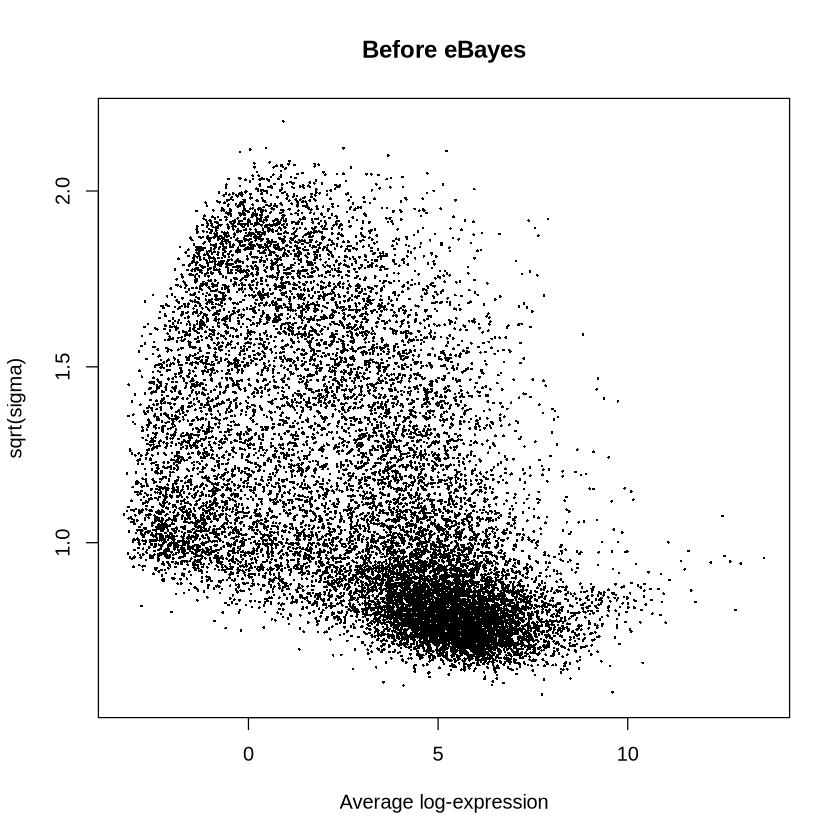

In [22]:
plotSA(fit, main = "Before eBayes") 

In [23]:
contrast_mat <- makeContrasts(
  clust13_vs_other  = Cluster_subcluster_13 - Cluster_subother,
  clust24_vs_other = Cluster_subcluster_24 - Cluster_subother,
  clust15_vs_other = Cluster_subcluster_15 - Cluster_subother,
  levels = design_mat
)

In [24]:
fit <- contrasts.fit(fit, contrast_mat)     # apply contrasts
fit2 <- eBayes(fit, trend = TRUE)           # empirical Bayes shrinkage

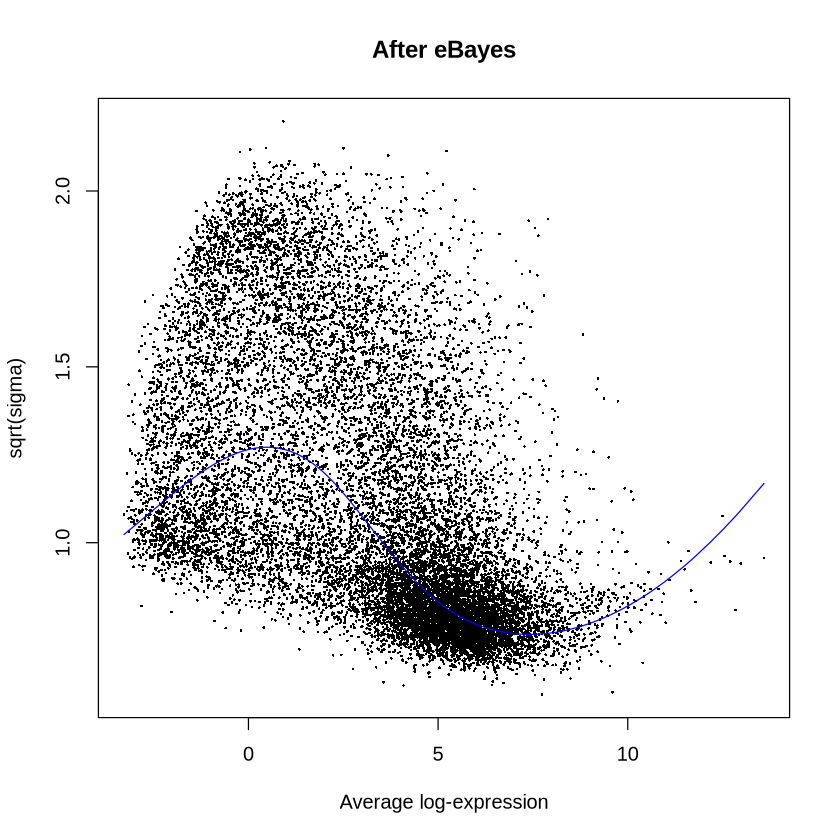

In [25]:
plotSA(fit2, main = "After eBayes")

In [26]:
topTable(fit2, coef = "clust13_vs_other", number = 10)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
RBBP4P1,-2.484185,-0.43634137,-13.94895,4.230806e-39,6.891559e-35,77.85690
YBX1P10,-2.976786,2.88431978,-13.22430,1.026210e-35,8.357965e-32,70.19453
HNRNPLP2,-2.218037,0.79712954,-12.75133,1.457797e-33,7.915350e-30,65.32314
PA2G4P5,-3.226244,-1.67286635,-12.72115,1.992675e-33,8.114669e-30,65.01597
RNPS1P1,-2.639272,0.07987999,-12.62589,5.329041e-33,1.736095e-29,64.04928
NUDCP2,-2.442828,-1.76158828,-12.47490,2.510565e-32,6.815766e-29,62.52625
EEF1A1P1,-4.385487,-0.41924361,-12.42047,4.377502e-32,1.018645e-28,61.97996
YBX1P1,-2.515517,2.92219115,-12.05164,1.818574e-30,3.702844e-27,58.31861
TEX14BP,-3.405050,-0.27758152,-11.88393,9.670141e-30,1.750188e-26,56.67727


In [27]:
saveRDS(fit2, file = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/deg_depMap_clusterwise.RDS')
# write.csv(key_clus_res, file = '../data_files/deg_keyClusters_depMap.csv')

In [31]:
cluster13_deg_res <- topTable(fit2, coef = "clust13_vs_other", number = Inf)

In [32]:
cluster24_deg_res <- topTable(fit2, coef = "clust24_vs_other", number = Inf)

In [33]:
cluster15_deg_res <- topTable(fit2, coef = "clust15_vs_other", number = Inf)

In [41]:
c13_deg_up <- cluster13_deg_res %>%
  filter(logFC > 1 & adj.P.Val < 0.05) %>%
  rownames()
c13_deg_down <- cluster13_deg_res %>%
  filter(logFC < -1 & adj.P.Val < 0.05) %>%
  rownames()
c24_deg_up <- cluster24_deg_res %>%
  filter(logFC > 1 & adj.P.Val < 0.05) %>%
  rownames()
c24_deg_down <- cluster24_deg_res %>%
  filter(logFC > 1 & adj.P.Val < 0.05) %>%
  rownames()
c15_deg_up <- cluster15_deg_res %>%
  filter(logFC > 1 & adj.P.Val < 0.05) %>%
  rownames()
c15_deg_down <- cluster15_deg_res %>%
  filter(logFC > 1 & adj.P.Val < 0.05) %>%
  rownames()

common_up_degs <- unique(c(c13_deg_up, c24_deg_up, c15_deg_up))
common_down_degs <- unique(c(c13_deg_down, c24_deg_down, c15_deg_down))

In [42]:
length(common_up_degs)
length(common_down_degs)

[1] 1842

[1] 3026

In [ ]:
# install.packages('VennDiagram')

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [38]:
library(VennDiagram)

Loading required package: grid



Loading required package: futile.logger



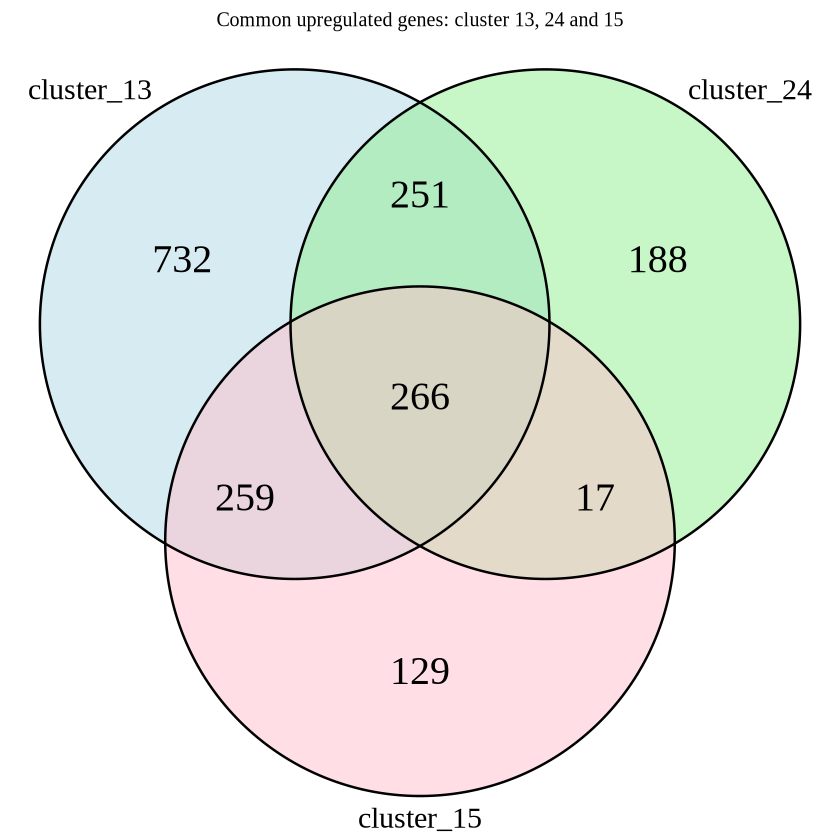

In [43]:
venn_lists <- list(cluster_13 = c13_deg_up, cluster_24 = c24_deg_up, cluster_15 = c15_deg_up)

# Create the Venn diagram
venn.plot <- venn.diagram(
  x = venn_lists,
  filename = NULL,  # To plot directly in RStudio Viewer
  fill = c("lightblue", "lightgreen", 'pink'),
  alpha = 0.5,
  cex = 2,
  cat.cex = 1.5,
  main = "Common upregulated genes: cluster 13, 24 and 15"
)

# Plot it
grid::grid.newpage()
grid::grid.draw(venn.plot)

In [47]:
pdf("/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/venn_cluster13_24_15_up.pdf", width = 8, height = 8)

venn.plot <- venn.diagram(
  x = venn_lists,
  filename = NULL,
  fill = c("lightblue", "lightgreen", "pink"),
  alpha = 0.5,
  cex = 2,
  cat.cex = 1.5,
  main = "Common upregulated genes: cluster 13, 24 and 15"
)

grid::grid.newpage()
grid::grid.draw(venn.plot)

dev.off()

pdf 
  2

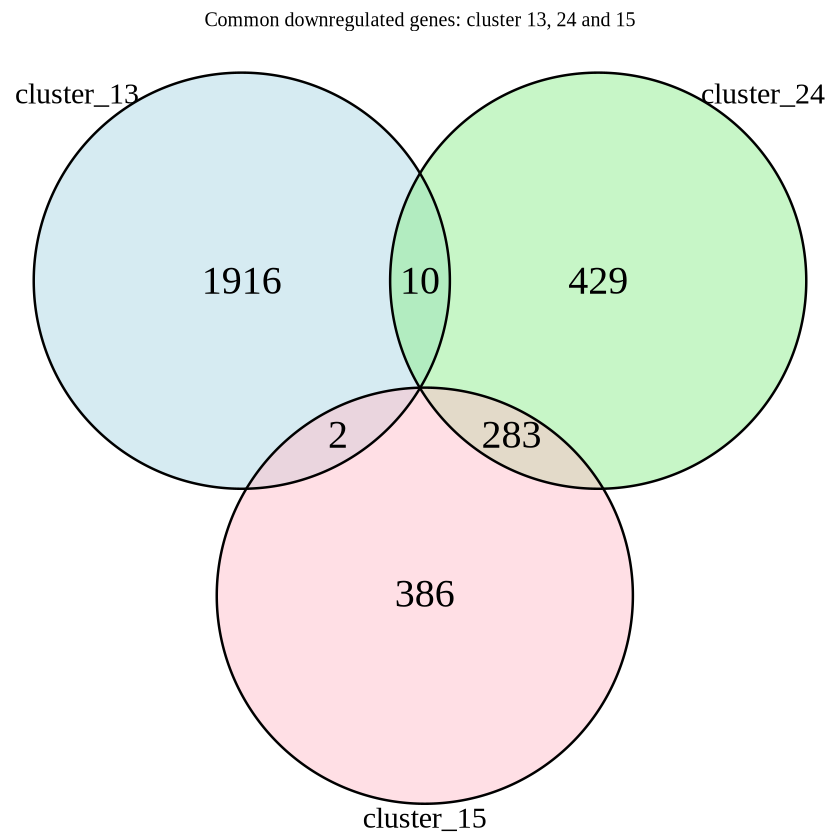

In [44]:
venn_lists2 <- list(cluster_13 = c13_deg_down, cluster_24 = c24_deg_down, cluster_15 = c15_deg_down)

# Create the Venn diagram
venn.plot <- venn.diagram(
  x = venn_lists2,
  filename = NULL,  # To plot directly in RStudio Viewer
  fill = c("lightblue", "lightgreen", 'pink'),
  alpha = 0.5,
  cex = 2,
  cat.cex = 1.5,
  main = "Common downregulated genes: cluster 13, 24 and 15"
)

# Plot it
grid::grid.newpage()
grid::grid.draw(venn.plot)

In [46]:
pdf("/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/venn_cluster13_24_15_down.pdf", width = 8, height = 8)

venn.plot <- venn.diagram(
  x = venn_lists2,
  filename = NULL,
  fill = c("lightblue", "lightgreen", "pink"),
  alpha = 0.5,
  cex = 2,
  cat.cex = 1.5,
  main = "Common downregulated genes: cluster 13, 24 and 15"
)

grid::grid.newpage()
grid::grid.draw(venn.plot)

dev.off()

pdf 
  2

In [45]:
write.csv(cluster13_deg_res, file = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/EGFR_Erlotinib_optuna_cluster13_deg.csv')
write.csv(cluster24_deg_res, file = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/EGFR_Erlotinib_optuna_cluster25_deg.csv')
write.csv(cluster15_deg_res, file = '/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/EGFR_Erlotinib_optuna_cluster15_deg.csv')

#### Heatmap of top 10 DEGs based on benefit score

In [48]:
deg_df <- read.csv('/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Data/depMap_benefitscore_deg_28122025_optuna.csv',header = TRUE, row.names = 1)
head(deg_df)

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
SLC4A2,-0.7545892,7.2230569,-12.31535,1.251082e-31,2.037887e-27,60.83241
ZCCHC24,-1.7015602,3.1702278,-11.63995,1.053423e-28,7.365206e-25,54.24360
SLC15A2,1.8095449,0.6344019,11.61410,1.356475e-28,7.365206e-25,53.99633
PPP4R3A,0.4713194,6.2819375,11.45253,6.535546e-28,2.661438e-24,52.45876
PLOD3,-1.0380196,6.4178663,-11.04999,3.080775e-26,1.003655e-22,48.69183
C1orf74,0.7908095,3.2233668,10.91782,1.069488e-25,2.903483e-22,47.47539


In [49]:
top5_up <- deg_df %>%
  filter(logFC > 1, adj.P.Val < 0.05) %>%
  arrange(desc(logFC)) %>%      # rank by strongest upregulation
  slice_head(n = 5) %>%
  rownames()

top5_down <- deg_df %>%
  filter(logFC < -1, adj.P.Val < 0.05) %>%
  arrange(logFC) %>%            # most negative first
  slice_head(n = 5) %>%
  rownames()

In [54]:
top_degs <- c(top5_up, top5_down)
top_degs

[1] "DAPP1"   "SYK"     "FGD3"    "BSPRY"   "IRF6"    "COL6A2"  "VIM.AS1"
 [8] "ALPK2"   "SPARC"   "MLPH"

In [53]:
library(ComplexHeatmap)

ComplexHeatmap version 2.22.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite either one:
- Gu, Z. Complex Heatmap Visualization. iMeta 2022.
- Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
    genomic data. Bioinformatics 2016.


The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




In [55]:
heatmap_exp <- exp_data[top_degs,]
head(heatmap_exp)

,22RV1,2313287,253J,253JBV,42MGBA,5637,639V,647V,697,769P,⋯,WM88,WM983B,WSUNHL,YAPC,YD15,YD38,YD8,YH13,YKG1,ZR751
DAPP1,-2.955644,4.324891,-3.5856661,-4.43543543,-4.776740,6.1673572,-5.50221348,5.408980,-2.9631032,-2.992357,⋯,-1.3707909,-1.8476459,7.001481,4.553191,4.037342,6.005410,-0.3508386,-3.0907743,-6.640645,2.268376
SYK,4.729455,5.604586,-2.2500631,-3.74355773,-3.302809,6.1934937,-1.41475064,5.627012,6.4130515,-2.817270,⋯,0.1066871,-0.3142137,8.899279,5.881948,2.753779,4.852168,-1.3245273,0.6958221,1.999600,3.499156
FGD3,1.855142,1.567587,1.1383604,2.72288295,-3.423103,3.2536540,0.09557306,3.489908,3.9570484,-1.679767,⋯,0.6124658,-2.4710826,4.511154,4.231956,2.757450,2.568512,1.6991769,-0.9752971,-3.367627,4.258383
BSPRY,3.969564,5.617069,-3.5856661,-5.32852023,-4.776740,0.8766704,-4.85013678,4.456176,-0.5951278,-2.992357,⋯,-3.0008413,-2.0081106,0.117177,3.635584,-2.107883,4.824852,-3.1760048,-1.8683819,-4.318717,5.229094
IRF6,4.455443,6.324671,-1.2914830,-1.79602515,-2.165305,8.7853798,-2.20104394,6.659029,-2.3396666,-3.088572,⋯,-0.9502153,-1.2048025,-3.395529,5.979936,7.223283,8.615997,2.6678480,1.4901751,3.104749,6.085471
COL6A2,-2.297750,-1.638408,0.7601087,-0.02213299,11.575735,9.4025396,6.02407615,2.275762,-0.2596673,7.035326,⋯,4.3927023,5.5568234,-3.609654,6.356708,1.777475,1.856221,8.1121341,10.3875824,8.717170,1.482082


In [65]:
table(metadata_df$Benefit_Score_cat)


high_score  low_score 
       343        343 

In [67]:
column_ha <- HeatmapAnnotation(scores = metadata_df$Benefit_Score_cat, col = list(bar = c("high_score" = "green", "low_score" = "red")))

In [64]:
# library(viridis)
library(circlize)

circlize version 0.4.17
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

This message can be suppressed by:
  suppressPackageStartupMessages(library(circlize))




In [70]:
metadata_df <- metadata_df %>%
  arrange(Benefit_Score_cat)

In [71]:
exp_data_sorted <- heatmap_exp[, rownames(metadata_df), drop = FALSE]

In [75]:
column_ha <- HeatmapAnnotation(
  scores = metadata_df$Benefit_Score_cat,
  col = list(
    scores = c(
      "high_score" = "blue",
      "low_score"  = "red"
    )
  )
)

In [77]:
library(viridis)

Loading required package: viridisLite



In [87]:
col_fun <- colorRamp2(
  seq(min(heatmap_exp, na.rm = TRUE),
      max(heatmap_exp, na.rm = TRUE),
      length.out = 50),
  turbo(50)
)

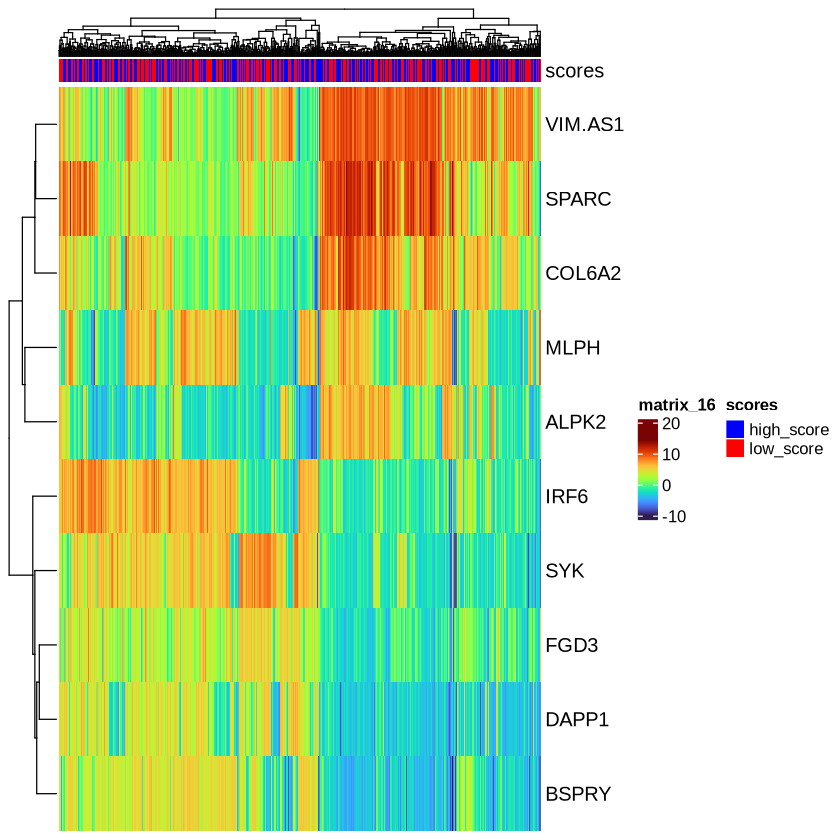

In [89]:
Heatmap(
  heatmap_exp,
  col = col_fun,
  show_column_names = FALSE,
  top_annotation = column_ha
)

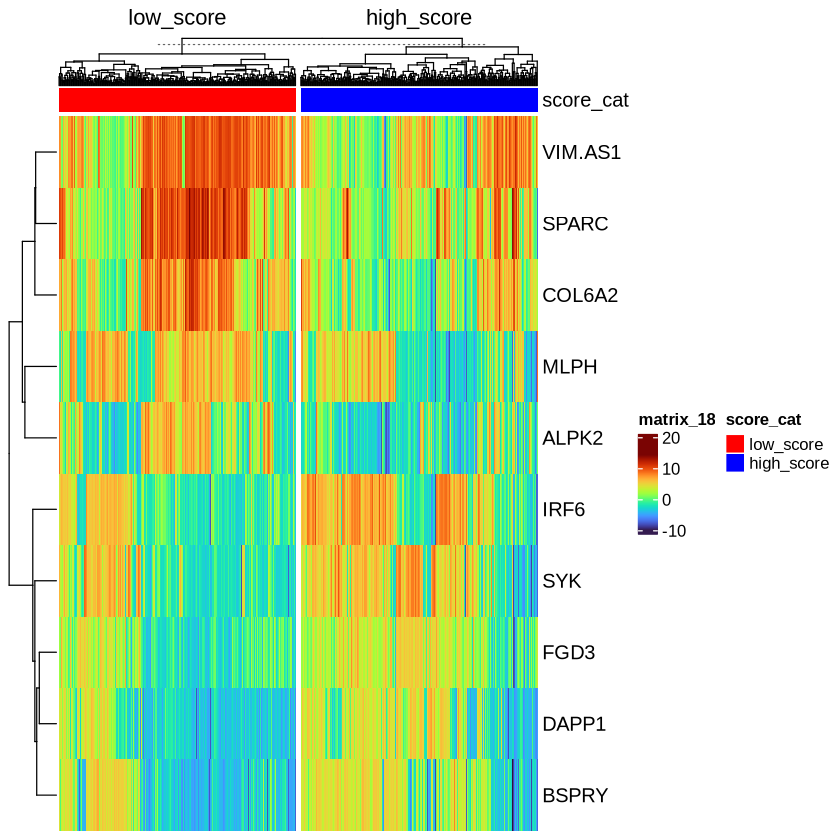

In [91]:
# ensure factor levels define the group order you want
metadata_df$Benefit_Score_cat <- factor(metadata_df$Benefit_Score_cat,
                                       levels = c("low_score","high_score"))  # adjust order

# re-order expression matrix to match metadata (just to be safe)
heatmap_exp <- heatmap_exp[, rownames(metadata_df), drop = FALSE]

column_ha <- HeatmapAnnotation(
  score_cat = metadata_df$Benefit_Score_cat,
  col = list(score_cat = c("low_score" = "red", "high_score" = "blue"))
)

ht <- Heatmap(
  heatmap_exp,
  top_annotation = column_ha,
  column_split = metadata_df$Benefit_Score_cat,   # <-- keeps groups contiguous
  cluster_columns = TRUE,                         # cluster columns
  cluster_rows = TRUE,
  show_column_names = FALSE,
  col = col_fun
)

draw(ht, annotation_legend_side = "right")


In [92]:
pdf("/home/sreeramp/cancer_dependency_project/nilabja/Approach3_Latent_factor/git_repo/Figs/top10DEG_scoreCat.pdf", width = 8, height = 10)

draw(ht, annotation_legend_side = "right")

dev.off()

pdf 
  2

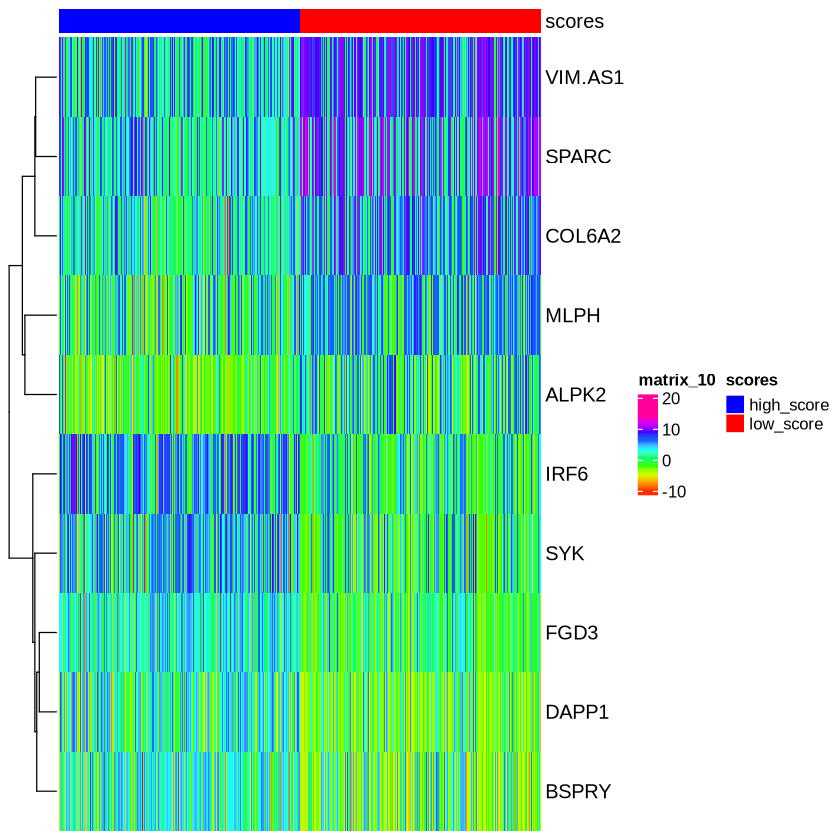

In [76]:
Heatmap(exp_data_sorted, col = rainbow(10),
  cluster_columns = FALSE,
  show_column_names = FALSE, top_annotation = column_ha)